# nb14 — Why does the joint model preserve identity but align captures poorly?

This notebook diagnoses **saved nb13 outputs without retraining**. CITE and Multiome
contain distinct cells. Shared donors, population labels and RNA provide a bridge;
protein and ATAC are never treated as directly paired measurements.

All neighborhood comparisons use the exact saved nb13 evaluation cells, Euclidean
distances without coordinate standardization, k=30 and ≥50 cells **per assay** for
alignment groups. Original units matter for coordinate perturbations. Report both
unweighted global mixing and composition-adjusted within-group mixing. Concern:
mixing ratio <0.5 **or** scaled centroid distance >1; supported: ratio ≥0.8 and
distance ≤0.5. These inherited thresholds are exploratory, not inferential tests.

Protein depth is observed only in CITE and ATAC depth only in Multiome. Missing
values remain missing throughout. RNA associations are assay-specific. The sample
is donor/assay quota sampled; it is not a population prevalence estimate.

Predeclared practical interpretation: mixing changes of 0.02 and purity losses of
0.02 are material; strong global depth association means |rho|≥0.5. Additional
deletion uses at most the three top coordinates meeting this threshold. These
choices are sensitivity diagnostics, not optimized correction rules. Module local
rho≥0.2 with loss≤0.05 is an exploratory preservation screen, not biological validation.

**Input limitation policy:** missing broad RNA counts or full modules produce explicit
unresolved results, never estimates inferred from earlier summary figures. The
broader panel comparison runs automatically when nb10 `shared_rna.h5ad` is restored.
The full restricted RNA PCA is still executed. Previously validated biology must
not be declared preserved on the basis of restricted-panel proxies alone.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image, Markdown
try:
    from google.colab import drive
except ImportError:
    BASE = Path.cwd().resolve()
    if not (BASE/'src').exists():
        BASE = BASE.parent
else:
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
assert (BASE/'src/joint_model_diagnostics.py').exists(), 'Set BASE to the repository root'
sys.path.insert(0, str(BASE))
from src.joint_model_diagnostics import DiagnosticRun
run = DiagnosticRun(BASE)
def show_figure(name):
    display(Image(filename=str(run.output/'figures'/f'{name}.png')))
print('Output:', run.output)
print('No model training, matching, imputation, or modification of notebooks 01–13.')

Output: /home/shoko/multiomics-relationship-modeling/results/joint_model_diagnostics
No model training, matching, imputation, or modification of notebooks 01–13.


# 1. Saved representation and metadata

## Scientific question

What representation and metadata are available for diagnosing the current joint model?

## Why this diagnostic matters

Recover exact cell identities and feature scope before interpreting depth. Selected-peak counts are not fragment counts; selected-gene counts are not full RNA library sizes.

In [2]:
display(run.load())
display(run.bundle['availability'])
display(run.obs.groupby(['assay', 'DonorID', 'Site']).size().rename('n_cells').to_frame())

{'cells': 141039,
 'evaluation_cells': 19670,
 'latent': 30,
 'RNA': 994,
 'ATAC': 20000,
 'protein': 134}

,field,status
0,shared_rna_counts,observed; selected RNA panel only
1,atac_counts,"observed Multiome; 20,000 selected peaks, not ..."
2,protein_counts,observed CITE; non-control ADT panel
3,cell_type_original,9683/19670 cells available
4,full_rna_counts,8296/19670 cells available
5,ATAC fragment/TSS/FRiP QC,not present in saved nb13 input
6,full RNA detected genes,not present; selected-panel detection reported...


n_cells
assay    DonorID Site          
CITE     10886   site1     1166
         11466   site3     1231
         12710   site2     1224
         15078   site1      224
                 site2      409
                 site3      376
                 site4      197
         16710   site2     1229
         18303   site1     1190
         19593   site4     1209
         28045   site3     1228
Multiome 10886   site1     1239
         11466   site3     1250
         12710   site2     1250
         15078   site1      412
                 site2      290
                 site4      546
         16710   site2     1250
         18303   site1      604
                 site3      646
         19593   site4     1250
         28045   site3     1250

# 2. Reproduce the nb13 baseline

## Scientific question

Can we reproduce the reported identity preservation and alignment concerns?

## Why this diagnostic matters

Stop on major discrepancies before any perturbation. Recompute purity, mixing, per-population and donor/type centroid metrics. Expected references: purity ≈90.6%, 11/13 and 39/42 concerns.

Evaluating joint_full (19670, 30)


,metric,actual,reference,tolerance,passed
0,cell_type_purity,9.064260e-01,0.906426,0.002,True
1,cross_capture_mixing,1.197272e-01,0.119727,0.002,True
2,types mixing_ratio,5.551115e-17,0.000000,0.005,True
3,types scaled_centroid_distance,1.058634e-06,0.000000,0.005,True
4,types statuses,0.000000e+00,0.000000,0.000,True
5,donors mixing_ratio,9.714451e-17,0.000000,0.005,True
6,donors scaled_centroid_distance,5.872463e-07,0.000000,0.005,True
7,donors statuses,0.000000e+00,0.000000,0.000,True
8,problematic_cell_types,1.100000e+01,11.000000,0.000,True
9,evaluable_cell_types,1.300000e+01,13.000000,0.000,True


,cell_type_purity,cross_capture_mixing,problematic_cell_types,evaluable_cell_types,problematic_donor_celltypes,evaluable_donor_celltypes
0,0.906426,0.119727,11,13,39,42


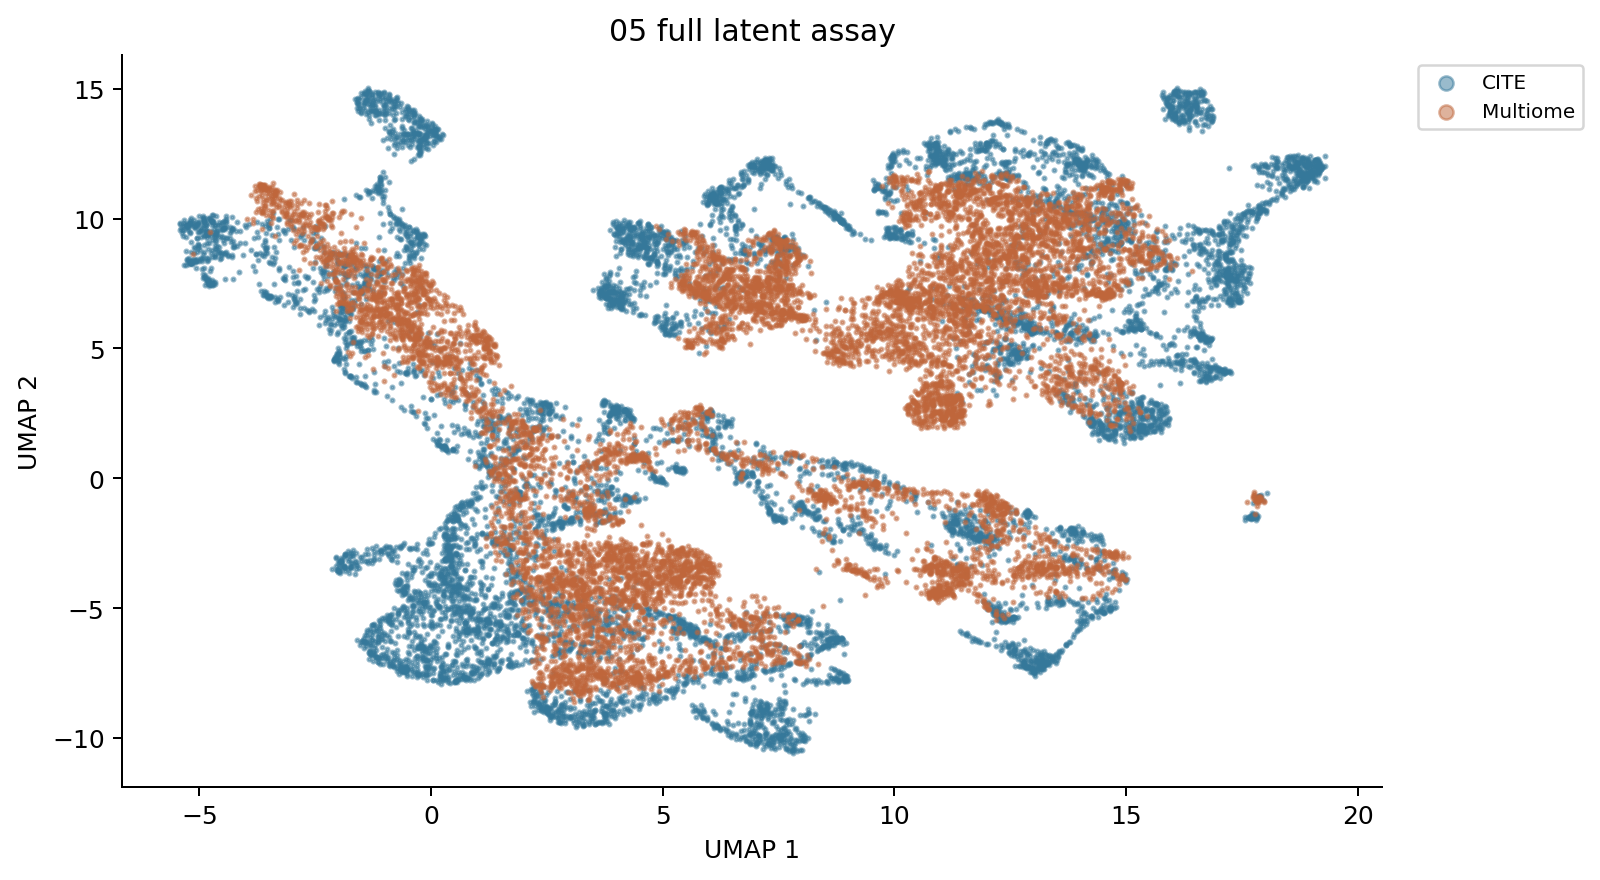

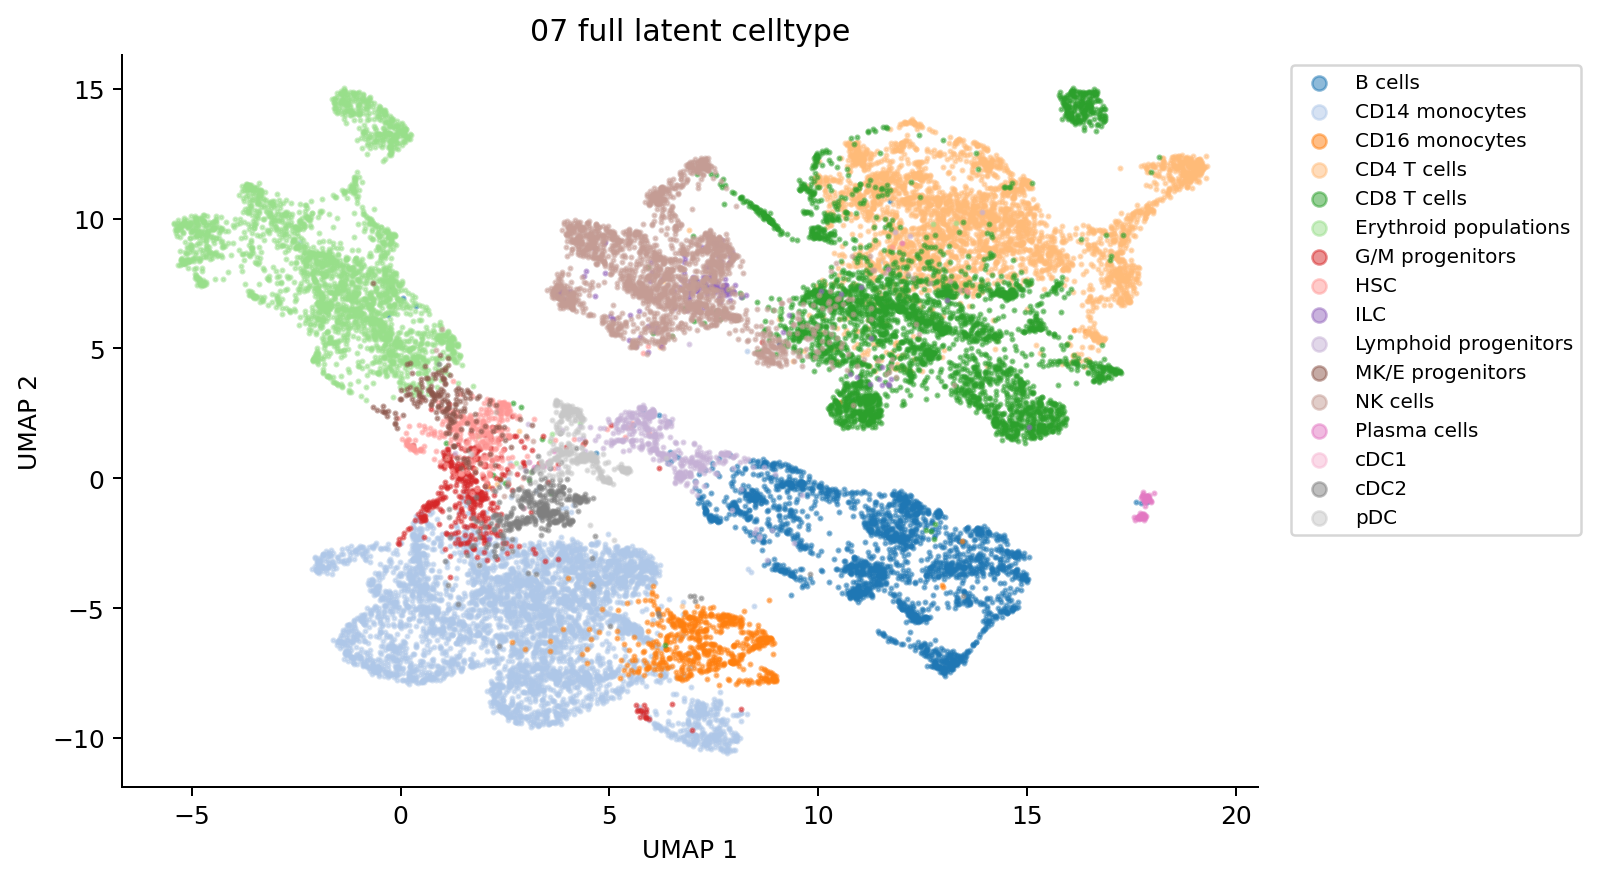

In [3]:
display(run.baseline())
display(pd.DataFrame([run.results['joint_full']['summary']]))
show_figure('05_full_latent_assay')
show_figure('07_full_latent_celltype')

# 3. Every latent dimension: technical and biological associations

## Scientific question

Is technical depth concentrated in one coordinate or distributed across the representation?

## Why this diagnostic matters

Spearman and log-depth Pearson correlations quantify continuous effects; unadjusted eta-squared quantifies categorical associations. These effects overlap and cannot be added as independent variance components.

In [4]:
display(run.associations())
print('Strongest zero-based coordinate:', run.top)
print('Coordinates meeting |rho| >= 0.5:', run.selected)

,protein_counts CITE rho,shared_rna_counts CITE rho,shared_rna_counts Multiome rho,full_rna_counts CITE rho,rna_detected_genes_994 CITE rho,rna_detected_genes_994 Multiome rho,atac_counts Multiome rho,assay eta2,DonorID eta2,Site eta2,cell_type_harmonized eta2
dimension,,,,,,,,,,,
5,-0.955949,-0.472790,-0.352868,-0.522425,-0.457035,-0.251116,0.096605,0.019350,0.235830,0.259751,0.033236
14,0.731011,0.421068,0.217681,0.567461,0.182950,0.154167,0.234528,0.078714,0.322695,0.313879,0.374370
28,-0.696829,-0.615878,-0.011364,-0.676766,-0.386140,-0.055881,-0.085507,0.102368,0.132433,0.113136,0.165729
22,-0.692801,-0.418117,-0.420327,-0.565566,-0.391940,-0.355856,-0.149458,0.026721,0.444143,0.546615,0.064888
3,-0.638289,-0.201941,-0.163450,-0.358773,-0.153398,-0.196848,-0.132591,0.004906,0.340012,0.312787,0.305893
9,0.619012,0.451585,-0.038370,0.515690,0.488428,-0.135891,0.020641,0.137092,0.298621,0.269988,0.265216
27,0.554964,0.379949,0.117019,0.398588,0.434520,0.143662,0.152622,0.428307,0.089170,0.074951,0.164195
26,-0.476220,-0.125637,-0.044909,-0.324134,-0.141733,-0.062668,-0.130937,0.000418,0.264285,0.295325,0.372787
4,-0.413688,-0.455303,-0.208291,-0.341934,-0.400554,-0.139523,-0.133550,0.491163,0.046317,0.018033,0.343040


Strongest zero-based coordinate: 5
Coordinates meeting |rho| >= 0.5: [5, 14, 28, 22, 3, 9, 27]


# 4. Depth within biological strata

## Scientific question

Could the protein-depth association simply reflect population composition, or general sequencing depth?

## Why this diagnostic matters

Use ≥50 measured cells per assay × donor × harmonized cell type. Compare protein, RNA and ATAC separately; report signed and absolute rho, IQR, and effect thresholds. Strata sharing donors are not independent biological replicates.

,variable,assay,dimension,n_evaluable,median,q25,q75,median_absolute,positive,negative,abs_gt_0.3,abs_gt_0.5,abs_gt_0.7
0,atac_counts,Multiome,3,47,-0.160952,-0.272766,-0.052808,0.169233,0.191489,0.808511,0.170213,0.000000,0.000000
1,atac_counts,Multiome,5,47,0.232814,0.141421,0.337587,0.232814,0.957447,0.042553,0.319149,0.021277,0.000000
2,atac_counts,Multiome,9,47,-0.274399,-0.421970,-0.121366,0.274399,0.042553,0.957447,0.468085,0.148936,0.000000
3,atac_counts,Multiome,14,47,0.103070,0.017274,0.196918,0.122720,0.765957,0.234043,0.106383,0.021277,0.000000
4,atac_counts,Multiome,22,47,-0.096760,-0.173264,0.018565,0.113854,0.276596,0.723404,0.085106,0.000000,0.000000
5,atac_counts,Multiome,27,47,0.201312,0.101553,0.278841,0.203535,0.829787,0.170213,0.191489,0.021277,0.000000
6,atac_counts,Multiome,28,47,-0.138045,-0.243971,-0.019810,0.175730,0.191489,0.808511,0.191489,0.021277,0.000000
7,full_rna_counts,CITE,3,44,-0.131576,-0.347005,0.104804,0.241637,0.340909,0.659091,0.386364,0.159091,0.090909
8,full_rna_counts,CITE,5,44,-0.296102,-0.372344,-0.222541,0.296102,0.045455,0.954545,0.477273,0.090909,0.000000
9,full_rna_counts,CITE,9,44,0.153920,0.016576,0.290353,0.210645,0.750000,0.250000,0.295455,0.136364,0.022727


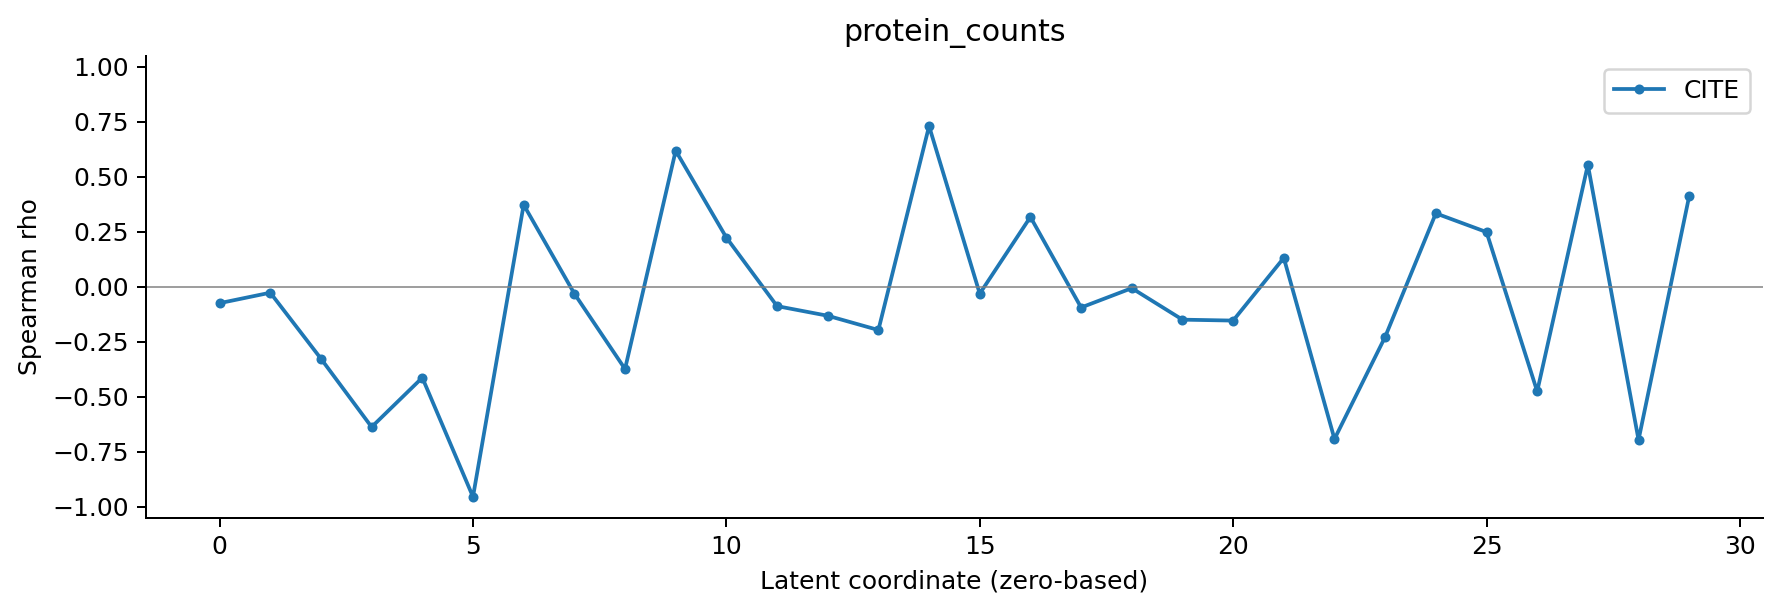

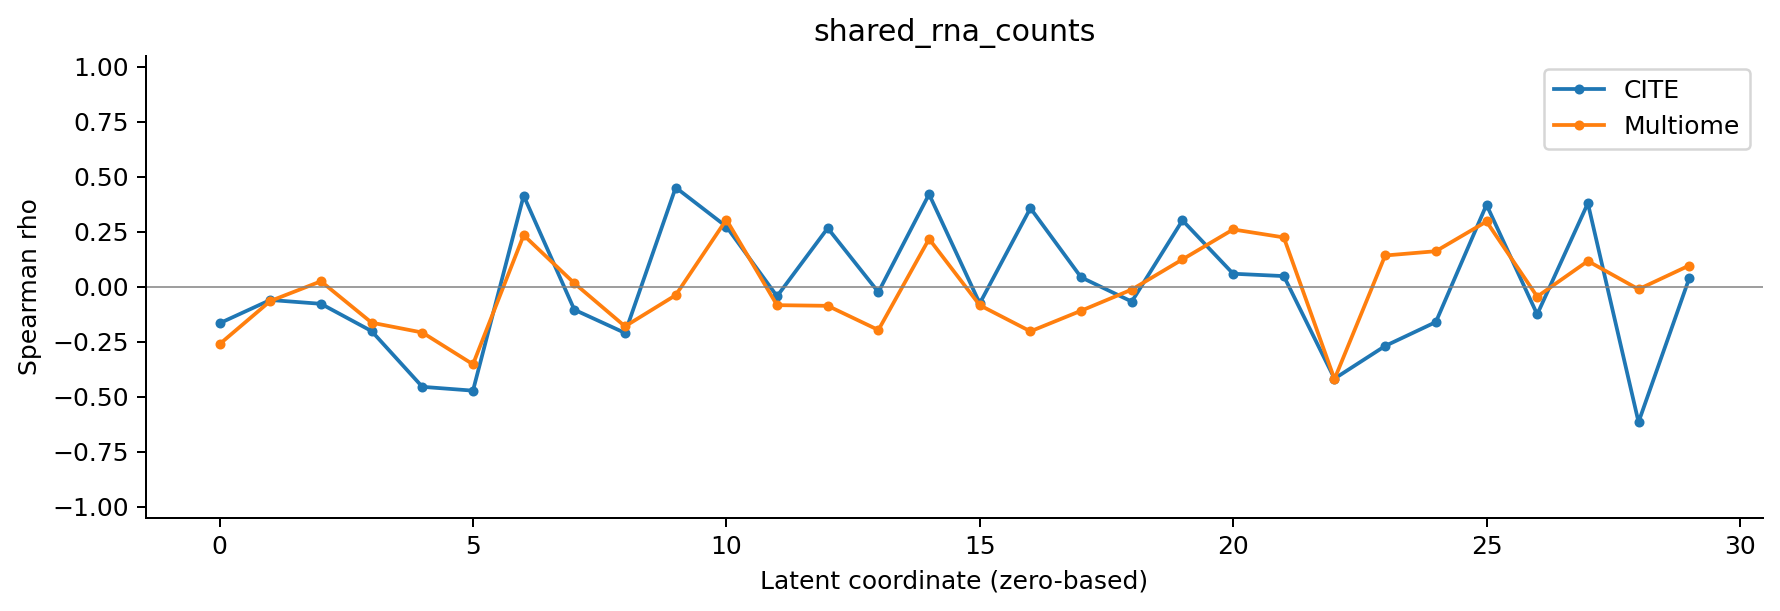

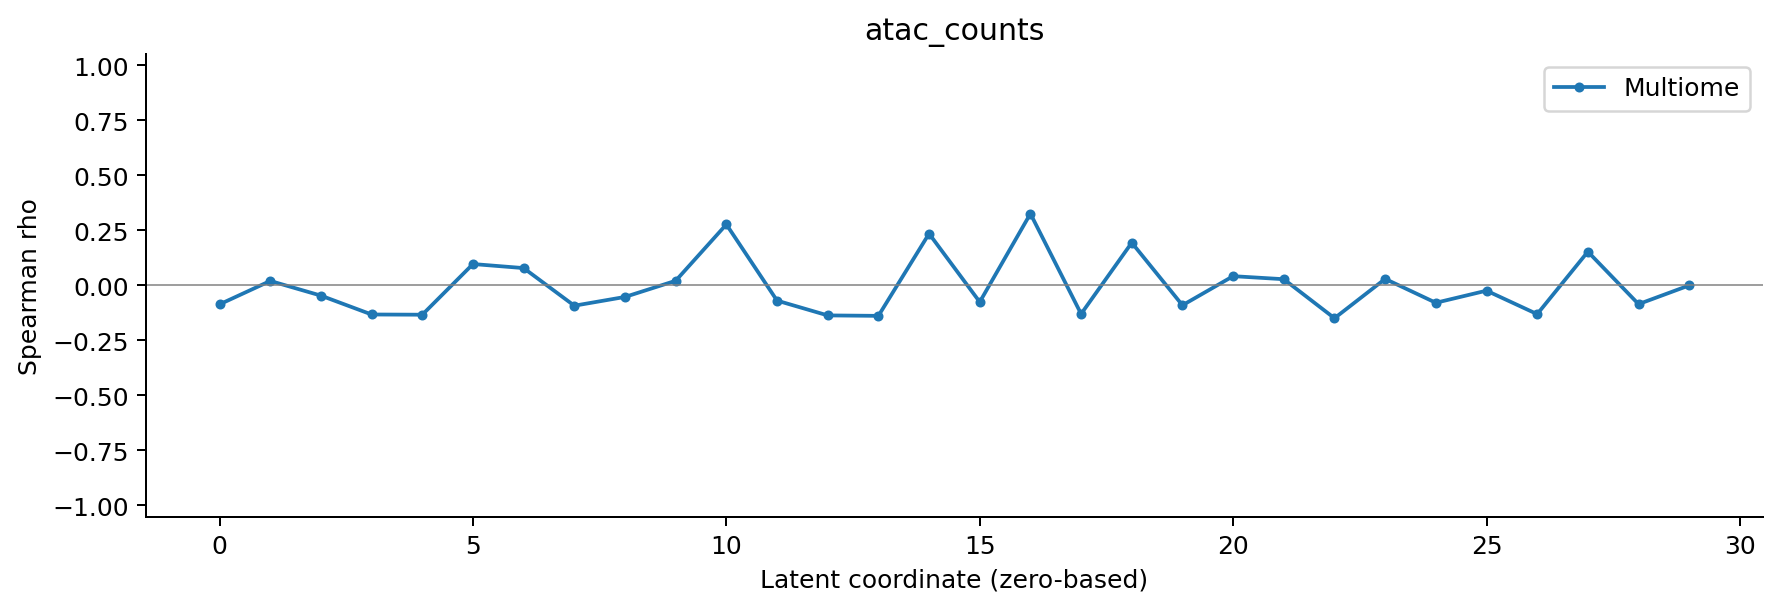

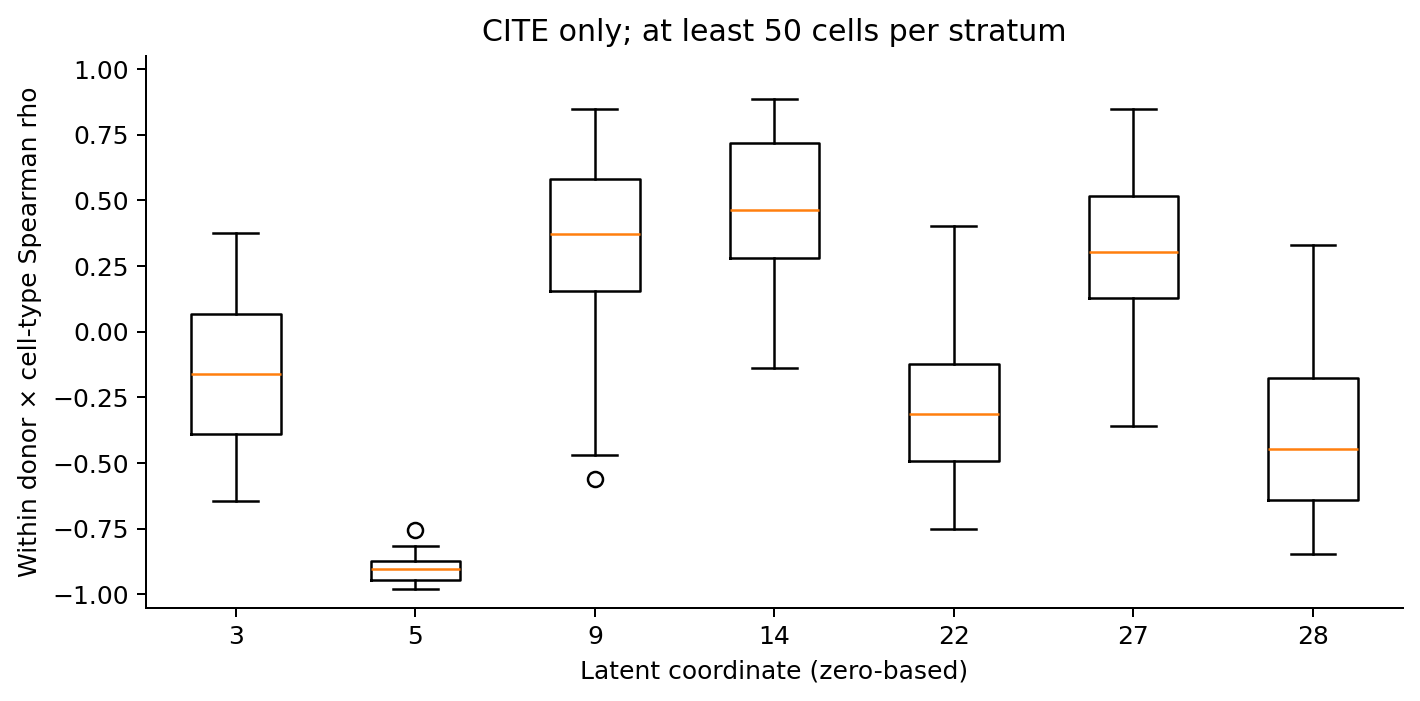

In [5]:
display(run.strata())
for name in ['01_latent_protein_depth', '02_latent_RNA_depth', '03_latent_ATAC_depth', '04_stratified_protein_depth']:
    show_figure(name)

# 5. Coordinate deletion: neighborhood sensitivity

## Scientific question

Does the strongest protein-depth-associated coordinate materially affect cross-capture alignment?

## Why this diagnostic matters

Recompute neighbors, UMAP and all alignment metrics after deletion; if justified also drop up to three strong coordinates. Deletion removes biological and technical information together and is not a valid final correction.

Evaluating minus_top1 (19670, 29)


Evaluating minus_top_depth (19670, 27)


,cell_type_purity,cross_capture_mixing,problematic_cell_types,evaluable_cell_types,problematic_donor_celltypes,evaluable_donor_celltypes
joint_full,0.906426,0.119727,11.0,13.0,39.0,42.0
minus_top1,0.904159,0.128599,11.0,13.0,37.0,42.0
minus_top_depth,0.904160,0.128717,11.0,13.0,37.0,42.0


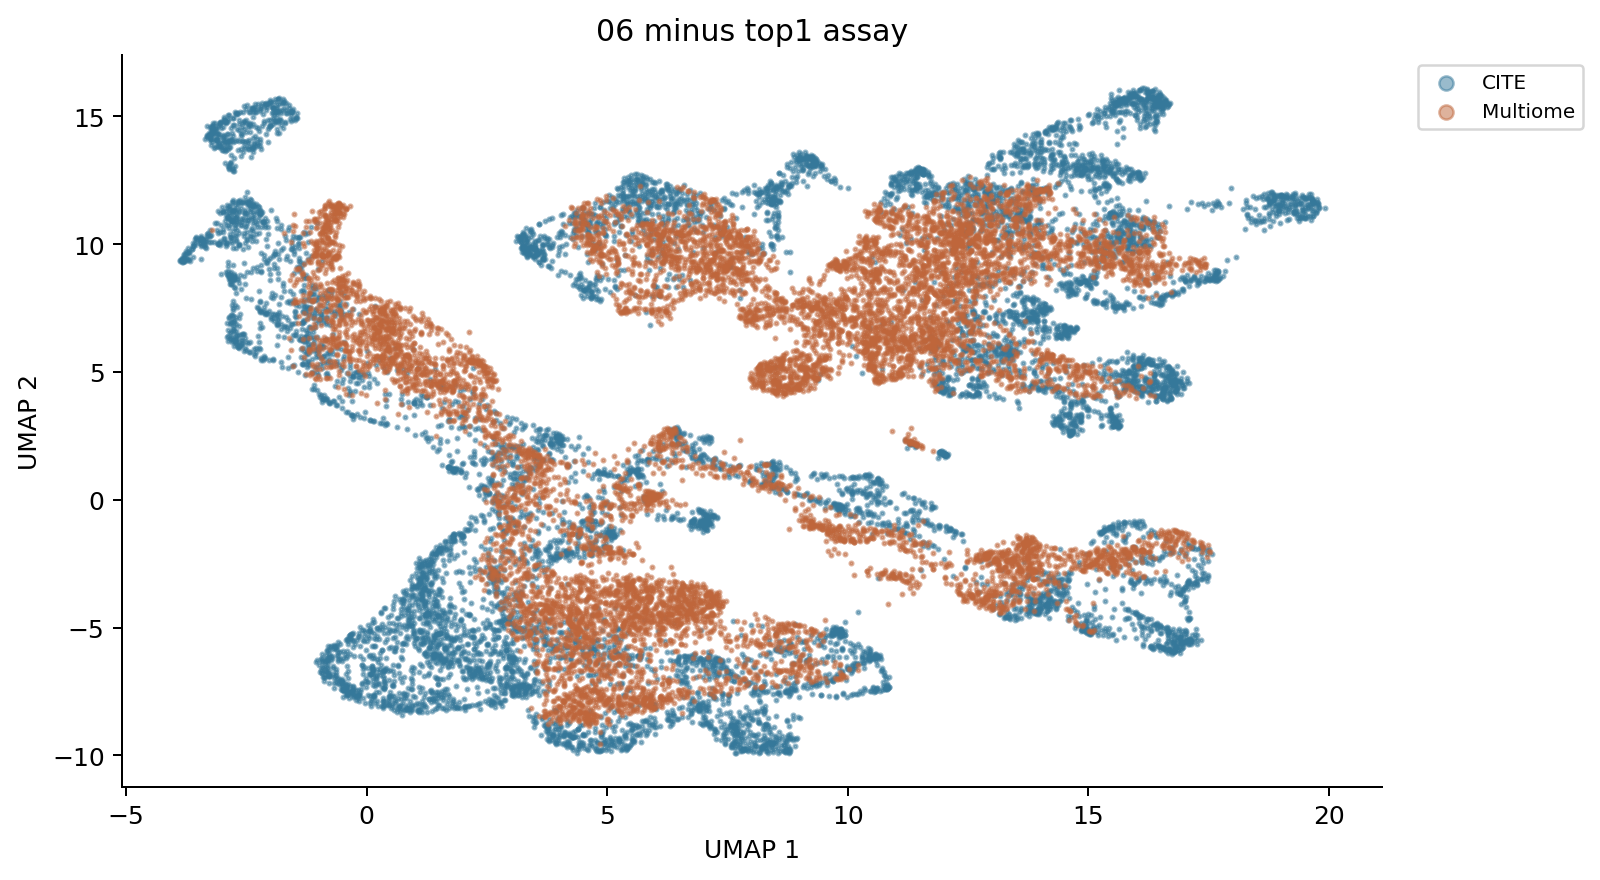

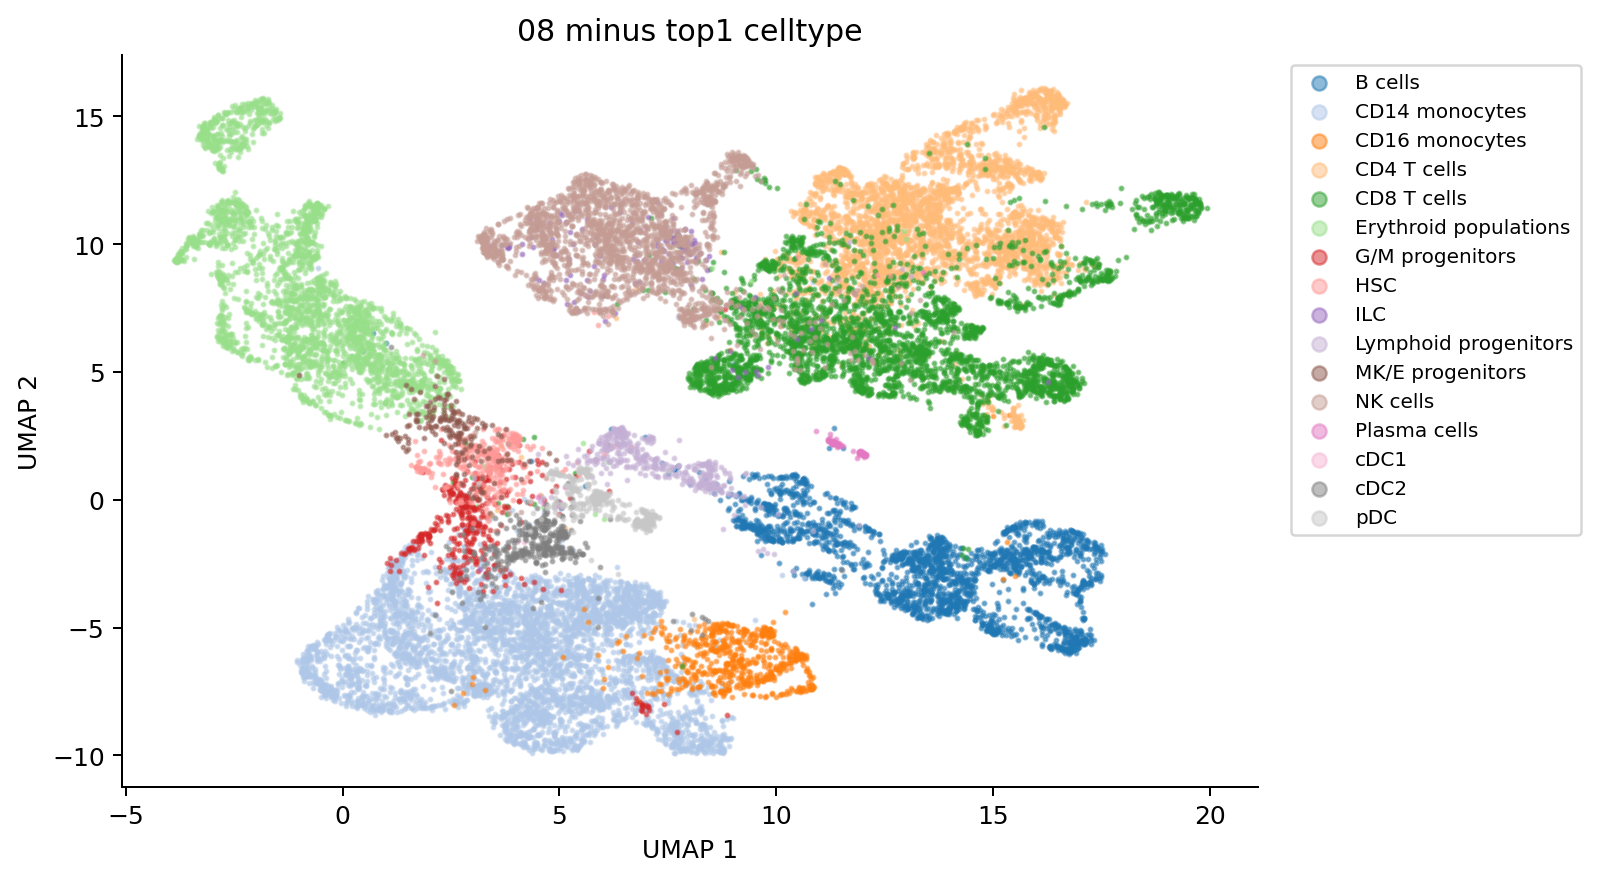

In [6]:
display(run.perturb())
show_figure('06_minus_top1_assay')
show_figure('08_minus_top1_celltype')

# 6. Centered depth residualization

## Scientific question

Is neighborhood separation sensitive specifically to the within-stratum depth component?

## Why this diagnostic matters

Within each adequately sized CITE donor/type stratum fit latent coordinate against log1p ADT total; subtract only the centered fitted depth term. Preserve stratum means and all Multiome values. This isolates within-stratum depth variation, but cannot remove between-capture offsets or infer unobserved Multiome protein depth. Labels are used: this is not a deployment method.

In [7]:
display(run.residualize())
display(pd.read_csv(run.output/'depth_coordinate/residualization_coefficients.csv'))

Evaluating depth_residualized (19670, 30)


{'cell_type_purity': np.float64(0.9067869852567362),
 'cross_capture_mixing': np.float64(0.11857820708354516),
 'problematic_cell_types': 11,
 'evaluable_cell_types': 13,
 'problematic_donor_celltypes': 39,
 'evaluable_donor_celltypes': 42}

,DonorID,cell_type_harmonized,n,slope,status
0,10886,B cells,111,-0.225588,centered depth term removed; intercept retained
1,10886,CD14 monocytes,189,-0.307120,centered depth term removed; intercept retained
2,10886,CD16 monocytes,39,NaN,insufficient cells/variation
3,10886,CD4 T cells,355,-0.264631,centered depth term removed; intercept retained
4,10886,CD8 T cells,131,-0.283783,centered depth term removed; intercept retained
...,...,...,...,...,...
112,28045,MK/E progenitors,13,NaN,insufficient cells/variation
113,28045,NK cells,92,-0.309623,centered depth term removed; intercept retained
114,28045,Plasma cells,7,NaN,insufficient cells/variation
115,28045,cDC2,39,NaN,insufficient cells/variation


# 7. Neighborhood dependence on ADT depth

## Scientific question

Are local neighborhoods organized by protein depth, and does deletion weaken that organization?

## Why this diagnostic matters

Compare query depth with the median of observed CITE neighbors; report observed-neighbor coverage and a same-donor/type random-neighbor reference of matched size. Multiome depth is not measurable. Compare type, assay, donor and site similarity on the same neighborhoods.

In [8]:
display(run.neighborhoods())

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

,representation,assay,DonorID,cell_type,n,depth_neighbor_rho,median_depth_gap,random_depth_gap,measured_fraction,same_assay,same_type,same_donor,same_site
0,joint_full,CITE,10886,B cells,111,0.768619,0.131347,0.289005,1.0,0.963063,0.980781,0.445646,0.893093
1,joint_full,CITE,10886,CD14 monocytes,189,0.713394,0.188115,0.306404,1.0,0.988007,0.981305,0.776190,0.972663
2,joint_full,CITE,10886,CD16 monocytes,39,0.437405,0.205598,0.243583,1.0,0.963248,0.896581,0.670085,0.845299
3,joint_full,CITE,10886,CD4 T cells,355,0.712237,0.167368,0.259963,1.0,0.988826,0.955681,0.773991,0.985728
4,joint_full,CITE,10886,CD8 T cells,131,0.693951,0.169589,0.226106,1.0,0.942748,0.858524,0.625445,0.931298
...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,minus_top1,Multiome,28045,Lymphoid progenitors,10,NaN,NaN,NaN,0.0,0.690000,0.763333,0.126667,0.300000
444,minus_top1,Multiome,28045,MK/E progenitors,32,NaN,NaN,NaN,0.0,0.862500,0.578125,0.365625,0.615625
445,minus_top1,Multiome,28045,NK cells,99,NaN,NaN,NaN,0.0,0.988215,0.812795,0.595960,0.766667
446,minus_top1,Multiome,28045,cDC2,18,NaN,NaN,NaN,0.0,0.950000,0.712963,0.261111,0.653704


# 8. Capture predictability on held-out donors

## Scientific question

Do depth-associated coordinates contribute to predicting assay identity?

## Why this diagnostic matters

Fit balanced logistic regression with training-fold-only standardization, holding out each donor in turn. Use identical folds for full and deleted spaces; report balanced accuracy, AUROC and standardized coefficients. The depth-coordinate selection is exploratory on the full diagnostic set, so this is not unbiased model selection. Label-informed residualization is excluded.

In [9]:
display(run.predictability())
display(run.predictions)

balanced_accuracy               auroc          
                             mean       std      mean       std
representation                                                 
joint_full               0.999745  0.000487  0.999999  0.000001
minus_top1               0.999695  0.000608  0.999999  0.000004
minus_top_depth          0.999540  0.001018  0.999996  0.000012

,representation,held_out_donor,n_test,balanced_accuracy,auroc
0,joint_full,10886,2405,1.000000,1.000000
1,joint_full,11466,2481,1.000000,1.000000
2,joint_full,12710,2474,1.000000,1.000000
3,joint_full,15078,2454,1.000000,1.000000
4,joint_full,16710,2479,1.000000,1.000000
5,joint_full,18303,2440,0.999200,0.999999
6,joint_full,19593,2459,0.998759,0.999997
7,joint_full,28045,2478,1.000000,1.000000
8,minus_top1,10886,2405,1.000000,1.000000
9,minus_top1,11466,2481,1.000000,1.000000


# 9. Restricted versus broader RNA information

## Scientific question

Does restricting RNA to the 994 shared genes limit alignment?

## Why this diagnostic matters

Fit identical 30-PC RNA-only representations on all saved cohort cells, evaluate on the same nb13 subset. Each panel uses raw counts → panel-wise CP10k → log1p → centered PCA, matching nb13’s RNA baseline. Broad RNA uses the complete common feature set saved by nb10 (12,059 genes in its manifest), without selecting new features. This measures panel restriction including its normalization denominator; it is not a pure gene-deletion experiment. An old integrated nb10 embedding is not a controlled substitute.

In [10]:
display(run.rna_panels())
display(pd.DataFrame({k:v['summary'] for k,v in run.results.items() if k.startswith('rna_')}).T)

Evaluating rna_994 (19670, 30)


Evaluating rna_broad (19670, 30)


,representation,genes,status
0,rna_994,994,executed
1,rna_broad,12059,executed


,cell_type_purity,cross_capture_mixing,problematic_cell_types,evaluable_cell_types,problematic_donor_celltypes,evaluable_donor_celltypes
rna_994,0.873664,0.018626,13.0,13.0,42.0,42.0
rna_broad,0.869087,0.002578,13.0,13.0,42.0,42.0


# 10. Validated program gene retention

## Scientific question

Are the CD14 inflammatory and TNF/NF-κB programs represented in the restricted panel?

## Why this diagnostic matters

Verify the frozen GMT fingerprint and use the original validated universe. Report original and retained genes, and discovery CD14 leading edges (union across assays). Module scoring reuses the project’s donor/assay/type-balanced reference moments. Compare full and restricted scores by donor/assay when full RNA is available. Restricted scores alone are explicitly marked as proxies.

In [11]:
display(run.modules())
print(run.module_status)

,module,original_genes,validated_universe_genes,retained,retained_percent,retained_leading_edge,missing_leading_edge
0,Inflammatory Response,200,128,34,17.0,ABCA1;AHR;BEST1;C5AR1;CSF3R;CXCL8;EREG;HBEGF;I...,ACVR2A;AQP9;ATP2A2;ATP2B1;BST2;CD14;CD48;CD55;...
1,TNF-alpha Signaling via NF-kB,200,160,38,19.0,ABCA1;BCL6;CD83;CXCL2;EGR1;G0S2;HBEGF;ICAM1;IL...,ATF3;ATP2B1;B4GALT1;B4GALT5;BCL2A1;BIRC2;BTG1;...


full available RNA module scores; restricted vs full comparisons executed


# 11. Population-specific failure modes

## Scientific question

Are problematic populations failing in the same way?

## Why this diagnostic matters

Allow multiple flags: large centroid shift, capture-specific neighborhoods, donor/site enrichment, purity below 0.8, or insufficient cells. Donor/site excess same-label fractions >0.15 are descriptive flags relative to within-type composition. Capture-specific neighborhoods suggest subclustering; they do not establish a distinct cluster mechanism.

In [12]:
display(run.failures())

,cell_type,main_failure_mode,evidence,severity
0,B cells,B: capture-specific neighborhoods (subclusteri...,DonorID excess same-label neighbors=0.380; Sit...,concern
1,CD14 monocytes,B: capture-specific neighborhoods (subclusteri...,DonorID excess same-label neighbors=0.570; Sit...,concern
2,CD16 monocytes,B: capture-specific neighborhoods (subclusteri...,DonorID excess same-label neighbors=0.382; Sit...,concern
3,CD4 T cells,B: capture-specific neighborhoods (subclusteri...,DonorID excess same-label neighbors=0.370; Sit...,concern
4,CD8 T cells,B: capture-specific neighborhoods (subclusteri...,DonorID excess same-label neighbors=0.510; Sit...,concern
5,Erythroid populations,B: capture-specific neighborhoods (subclusteri...,DonorID excess same-label neighbors=0.352; Sit...,concern
6,G/M progenitors,B: capture-specific neighborhoods (subclusteri...,DonorID excess same-label neighbors=0.217; Sit...,concern
7,HSC,B: capture-specific neighborhoods (subclusteri...,DonorID excess same-label neighbors=0.245; Sit...,concern
8,ILC,F: insufficient cells; E: weak biological sepa...,DonorID excess same-label neighbors=-0.001; Si...,insufficient cells
9,Lymphoid progenitors,C: donor-enriched neighborhoods; D: site-enric...,DonorID excess same-label neighbors=0.177; Sit...,partially supported


# 12. Donor × cell-type alignment groups

## Scientific question

What technical and sampling patterns accompany the 39/42 concern groups?

## Why this diagnostic matters

Save both capture centroids, counts, sites, technical medians and local mixing. Report group-level descriptive associations and donor-median correlations. Do not use cell counts as independent biological replicates. The donor/site contingency table exposes confounding.

In [13]:
display(run.donor_groups())
display(run.donor_table.drop(columns=[c for c in run.donor_table if '_centroid_' in c]))
display(pd.crosstab(run.obs.DonorID, run.obs.Site))

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

...

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

,level,variable,metric,n,spearman
0,donor median,n_CITE,mixing_ratio,8,0.476190
1,donor x cell type (dependent groups),n_CITE,mixing_ratio,42,-0.228544
2,donor median,n_CITE,scaled_centroid_distance,8,-0.690476
3,donor x cell type (dependent groups),n_CITE,scaled_centroid_distance,42,-0.116055
4,donor median,n_Multiome,mixing_ratio,8,0.666667
5,donor x cell type (dependent groups),n_Multiome,mixing_ratio,42,-0.293877
6,donor median,n_Multiome,scaled_centroid_distance,8,-0.809524
7,donor x cell type (dependent groups),n_Multiome,scaled_centroid_distance,42,-0.111602
8,donor median,CITE_protein_counts,mixing_ratio,8,-0.261905
9,donor x cell type (dependent groups),CITE_protein_counts,mixing_ratio,42,-0.303229


,DonorID,cell_type_harmonized,n_CITE,n_Multiome,sufficient_cells,cross_assay_fraction,expected_cross_fraction,mixing_ratio,centroid_distance,alignment_status,...,CITE_shared_rna_counts,CITE_full_rna_counts,CITE_rna_detected_genes_994,CITE_atac_counts,Multiome_sites,Multiome_protein_counts,Multiome_shared_rna_counts,Multiome_full_rna_counts,Multiome_rna_detected_genes_994,Multiome_atac_counts
0,10886,B cells,111,45,False,NaN,NaN,NaN,NaN,insufficient cells,...,709.0,5679.0,113.0,NaN,site1,NaN,279.0,NaN,101.0,6156.0
1,10886,CD14 monocytes,189,113,True,0.100297,0.501661,0.199930,0.877610,concern,...,1073.0,7192.0,127.0,NaN,site1,NaN,319.0,NaN,105.0,5259.0
2,10886,CD16 monocytes,39,40,False,NaN,NaN,NaN,NaN,insufficient cells,...,1192.0,NaN,131.0,NaN,site1,NaN,391.5,NaN,109.0,5516.0
3,10886,CD4 T cells,355,390,True,0.054937,0.500672,0.109727,0.768043,concern,...,681.0,6638.0,95.0,NaN,site1,NaN,234.0,NaN,88.0,6097.0
4,10886,CD8 T cells,131,281,True,0.091805,0.501217,0.183165,0.849244,concern,...,779.0,6260.0,108.0,NaN,site1,NaN,238.0,NaN,95.0,5914.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,28045,MK/E progenitors,13,32,False,NaN,NaN,NaN,NaN,insufficient cells,...,408.0,NaN,66.0,NaN,site3,NaN,340.0,NaN,121.5,5410.0
113,28045,NK cells,92,99,True,0.026555,0.502632,0.052833,0.858223,concern,...,273.5,1592.0,57.0,NaN,site3,NaN,226.0,NaN,96.0,3964.0
114,28045,Plasma cells,7,0,False,NaN,NaN,NaN,NaN,insufficient cells,...,2055.0,NaN,62.0,NaN,,NaN,NaN,NaN,NaN,NaN
115,28045,cDC2,39,18,False,NaN,NaN,NaN,NaN,insufficient cells,...,637.0,NaN,92.0,NaN,site3,NaN,310.5,NaN,113.5,4489.5


Site,site1,site2,site3,site4
DonorID,,,,
10886,2405,0,0,0
11466,0,0,2481,0
12710,0,2474,0,0
15078,636,699,376,743
16710,0,2479,0,0
18303,1794,0,646,0
19593,0,0,0,2459
28045,0,0,2478,0


# 13. CD14 gradient preservation across spaces

## Scientific question

Would improved mixing erase inflammatory or TNF/NF-κB gradients?

## Why this diagnostic matters

Quantify score versus neighbor-mean correlation within donor/assay CD14 cells, with 20 shuffled-score references. Also quantify cross-assay directional neighborhood score prediction within donors using the existing repository function. These descriptive RNA-based checks have RNA-input circularity and are not independent validation. Full RNA scores are required for a definitive preservation claim.

In [14]:
display(run.gradients())
print(run.module_status)
display(run.cross.groupby(['representation','module']).spearman.agg(['median','count']))

median  count
representation     module                                        
depth_residualized Inflammatory Response          0.422598     16
                   TNF-alpha Signaling via NF-kB  0.515678     16
joint_full         Inflammatory Response          0.415201     16
                   TNF-alpha Signaling via NF-kB  0.511932     16
minus_top1         Inflammatory Response          0.420672     16
                   TNF-alpha Signaling via NF-kB  0.501179     16
minus_top_depth    Inflammatory Response          0.420672     16
                   TNF-alpha Signaling via NF-kB  0.501207     16
rna_994            Inflammatory Response          0.655582     16
                   TNF-alpha Signaling via NF-kB  0.754413     16
rna_broad          Inflammatory Response          0.661285     16
                   TNF-alpha Signaling via NF-kB  0.749219     16

full available RNA module scores; restricted vs full comparisons executed


median  count
representation     module                                        
depth_residualized Inflammatory Response          0.343315     16
                   TNF-alpha Signaling via NF-kB  0.366250     16
joint_full         Inflammatory Response          0.338132     16
                   TNF-alpha Signaling via NF-kB  0.355769     16
minus_top1         Inflammatory Response          0.346075     16
                   TNF-alpha Signaling via NF-kB  0.381597     16
minus_top_depth    Inflammatory Response          0.345771     16
                   TNF-alpha Signaling via NF-kB  0.381981     16
rna_994            Inflammatory Response          0.614482     16
                   TNF-alpha Signaling via NF-kB  0.686798     16
rna_broad          Inflammatory Response          0.625828     16
                   TNF-alpha Signaling via NF-kB  0.708253     16

# 14. Protein preprocessing and feature-depth dependence

## Scientific question

Could the current protein input be unusually sensitive to library depth?

## Why this diagnostic matters

Audit nb11/nb13 raw-count preparation and compare raw/log1p ADT with explicitly defined within-cell centered log1p CLR. A transformation reducing feature-depth correlations is not evidence it would improve the joint model. Do not feed CLR into a count likelihood. No denoising or retraining is performed.

In [15]:
display(run.proteins())
display(Markdown((run.output/'depth_coordinate/protein_preprocessing.md').read_text()))

,median,max
transform,,
centered_log1p_CLR,0.230053,0.744536
log1p_ADT,0.596705,0.891534
raw_ADT,0.596705,0.891534


Repository nb11 prepare_cite excludes isotype/control proteins and supplies raw integer ADT counts to totalVI. nb13 reuses that 134-protein raw panel, with Multiome protein rows masked as missing. No external ADT normalization or isotype-based background correction precedes training. MultiVI uses a protein foreground/background count mixture, with learned protein background parameters; the model implementation has RNA and accessibility library encoders, not a separate observed ADT-total offset. A background mixture alone should not be equated with removal of library-depth effects. Feature diagnostics compare raw counts, log1p counts and within-cell centered log1p CLR. CLR is only a diagnostic feature transform; these values are not valid raw-count inputs to the existing likelihood. No saved totalVI denoised representation is available locally. No model was retrained.

# 15. Evidence table and final quantitative comparison

## Scientific question

Which hypotheses are supported by the executed results?

## Why this diagnostic matters

Keep unresolved hypotheses unresolved. The final protein-depth column is maximum within-CITE |rho| over dimensions; CD14 preservation is never declared from proxy scores alone. Global mixing improvement must be assessed alongside population alignment and biology.

,representation,RNA_genes,protein_depth_dependence,CD14_biology_preserved,cell_type_purity,cross_capture_mixing,problematic_cell_types,evaluable_cell_types,problematic_donor_celltypes,evaluable_donor_celltypes
0,joint_full,994,0.955949,preserved by exploratory thresholds,0.906426,0.119727,11,13,39,42
1,minus_top1,994,0.731011,preserved by exploratory thresholds,0.904159,0.128599,11,13,37,42
2,minus_top_depth,994,0.692801,preserved by exploratory thresholds,0.904160,0.128717,11,13,37,42
3,depth_residualized,994,0.849346,preserved by exploratory thresholds,0.906787,0.118578,11,13,39,42
4,rna_994,994,0.346576,preserved by exploratory thresholds,0.873664,0.018626,13,13,42,42
5,rna_broad,12059,0.390200,preserved by exploratory thresholds,0.869087,0.002578,13,13,42,42


,hypothesis,evidence_for,evidence_against,conclusion
0,H1: single protein-depth coordinate,Deletion mixing change +0.0089; residualizatio...,Purity change -0.0023; association/removal can...,unsupported
1,H2: broader protein-depth encoding,7 dimensions have global CITE |rho| >= 0.5; mu...,Feature-depth associations may include biologi...,unresolved
2,H3: restricted RNA information,Broad minus restricted RNA mixing -0.0160; pur...,Module gene retention alone does not establish...,unsupported
3,H4: population-specific failure,6 distinct combinations of descriptive flags,Threshold flags do not prove separate mechanis...,partially supported
4,H5: donor/site structure,13 populations have donor/site enrichment flags,Donor and site are confounded; local enrichmen...,partially supported


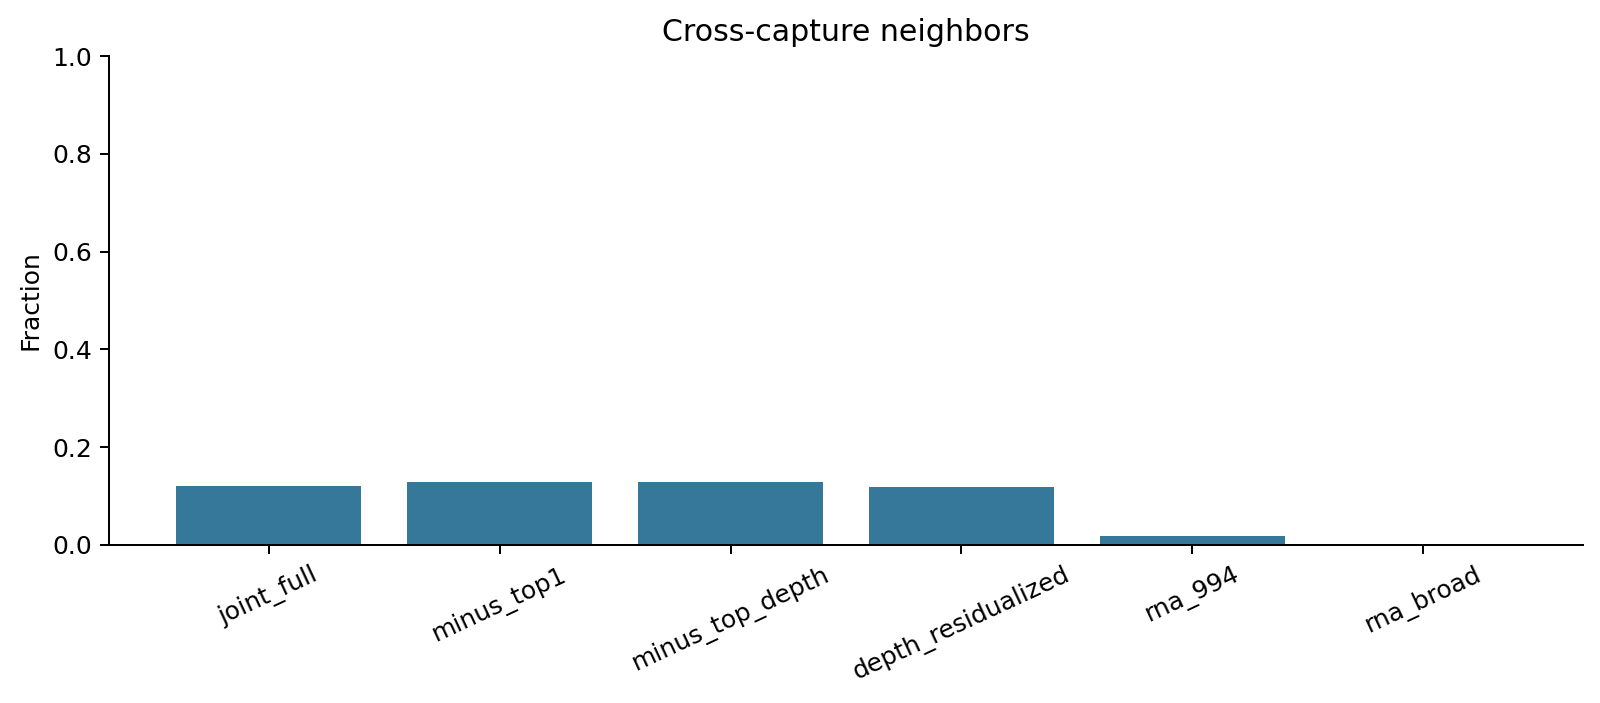

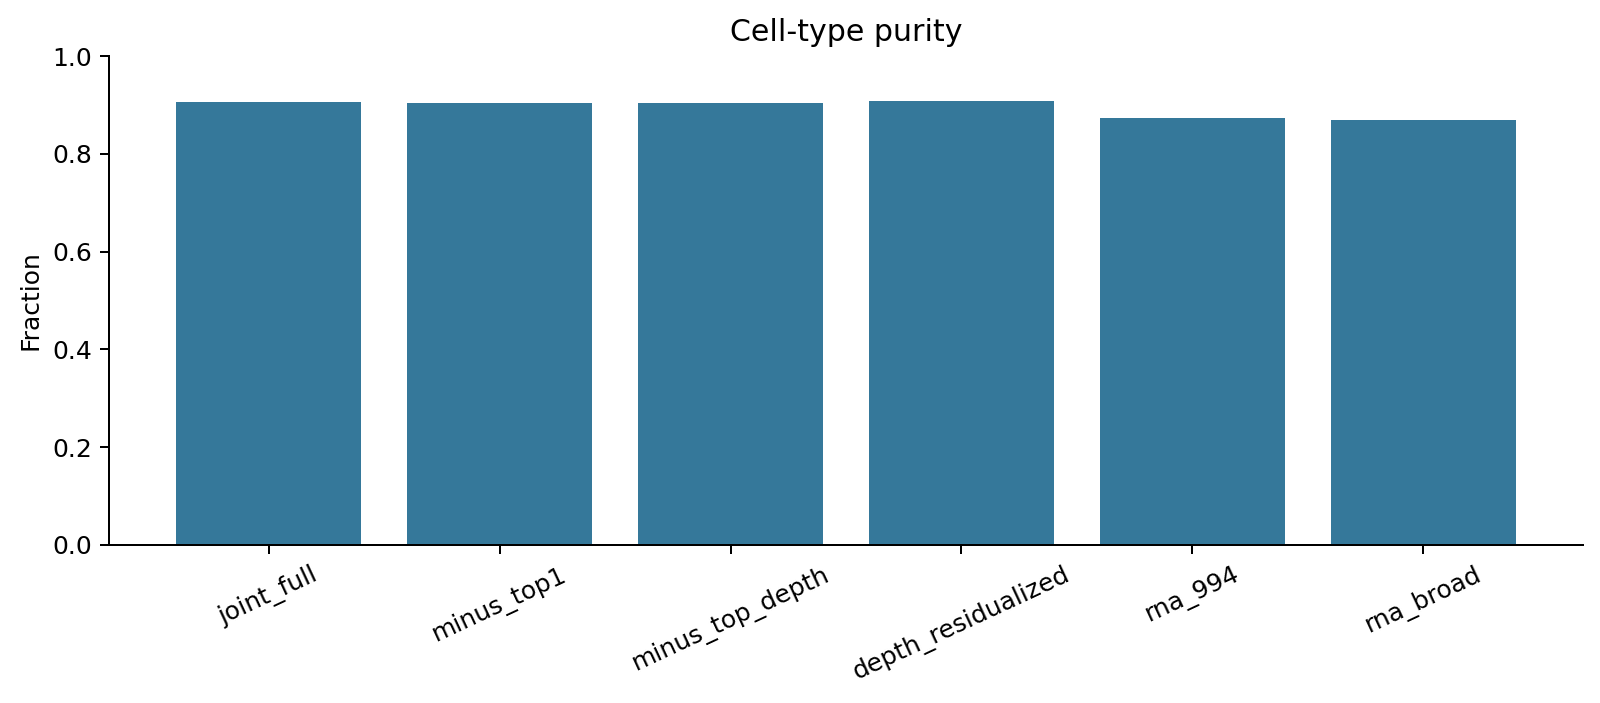

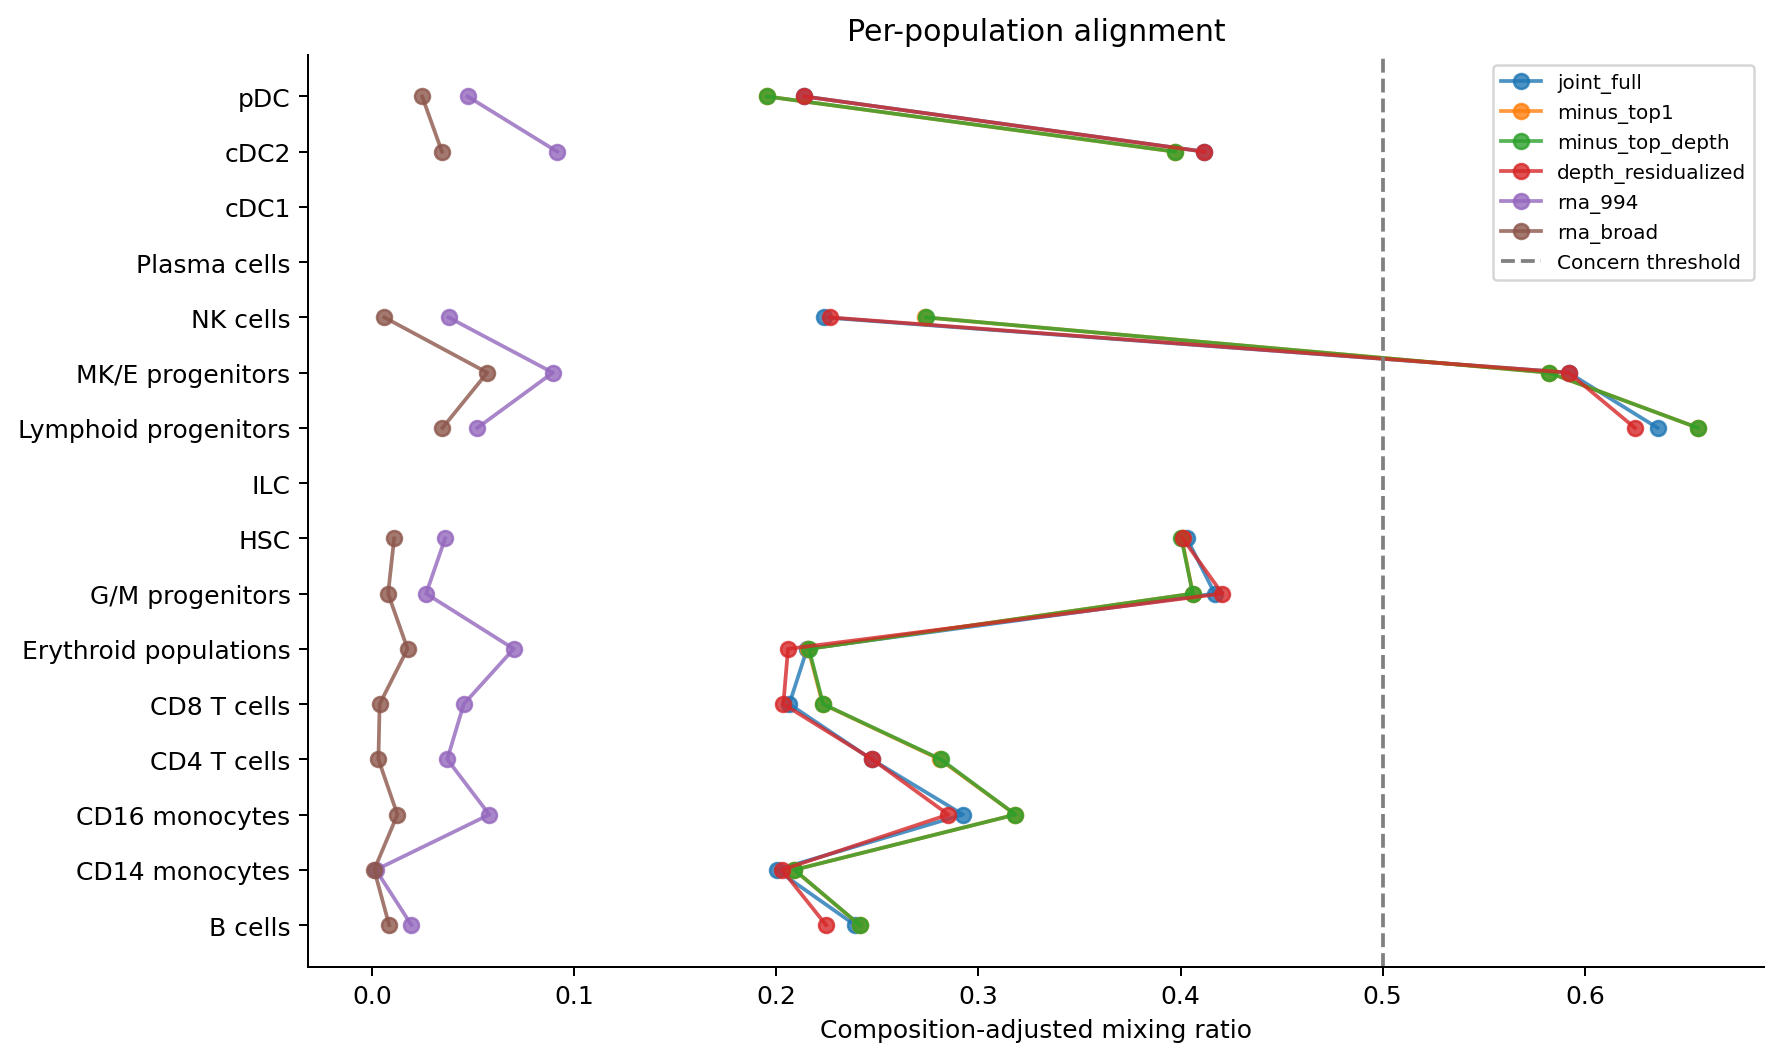

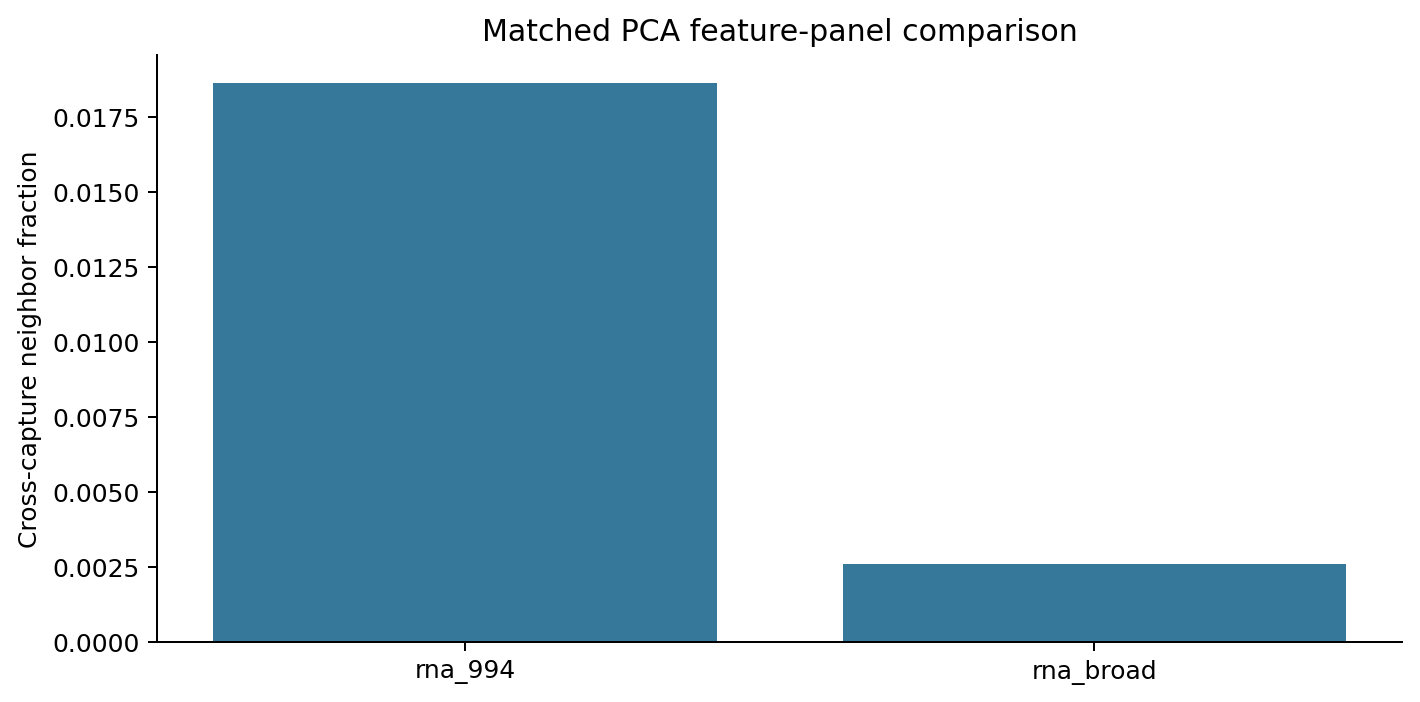

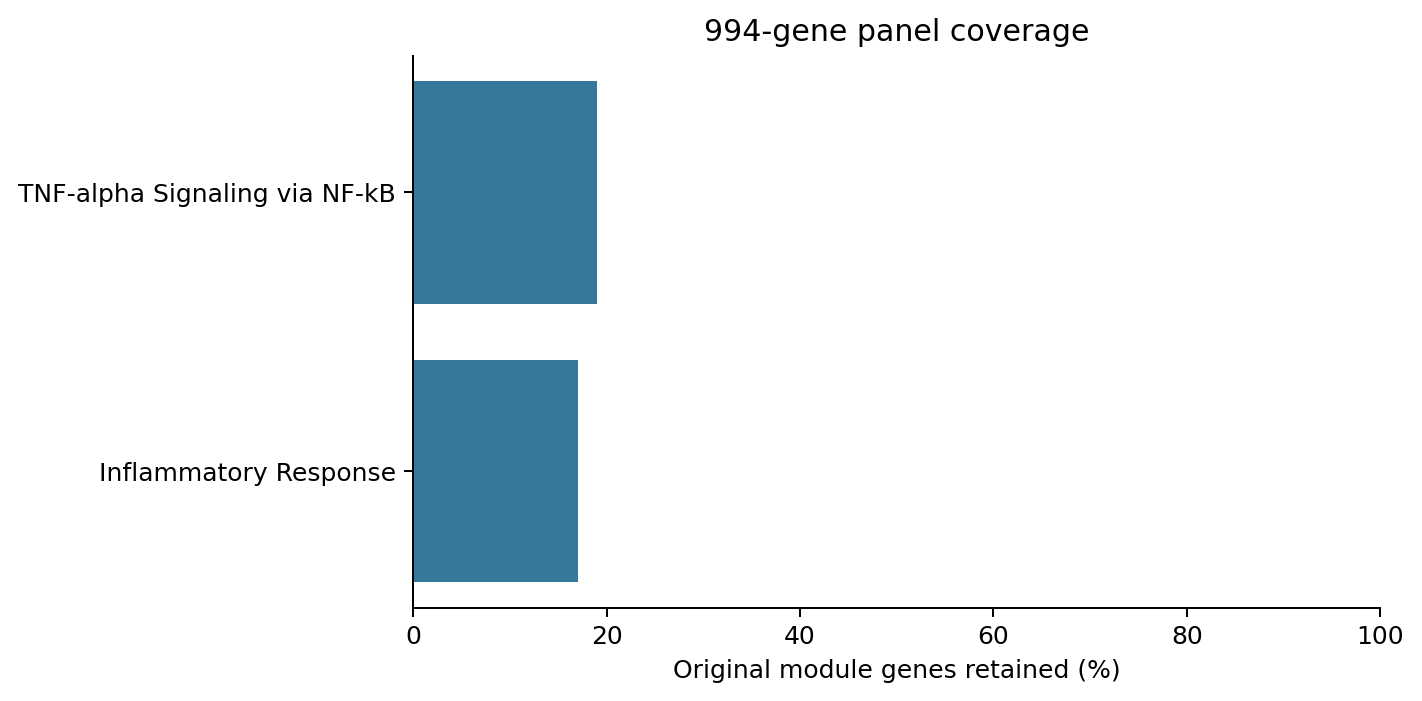

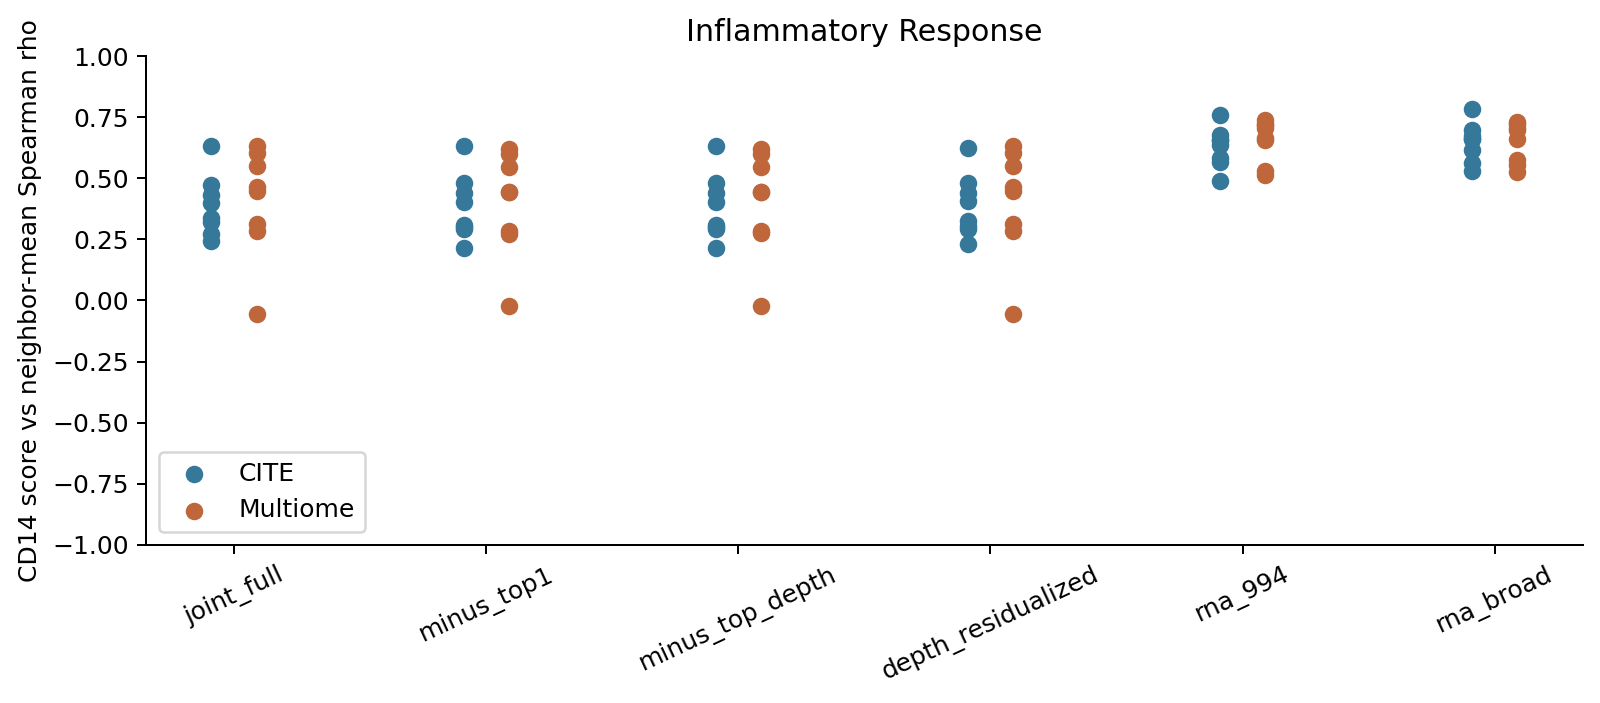

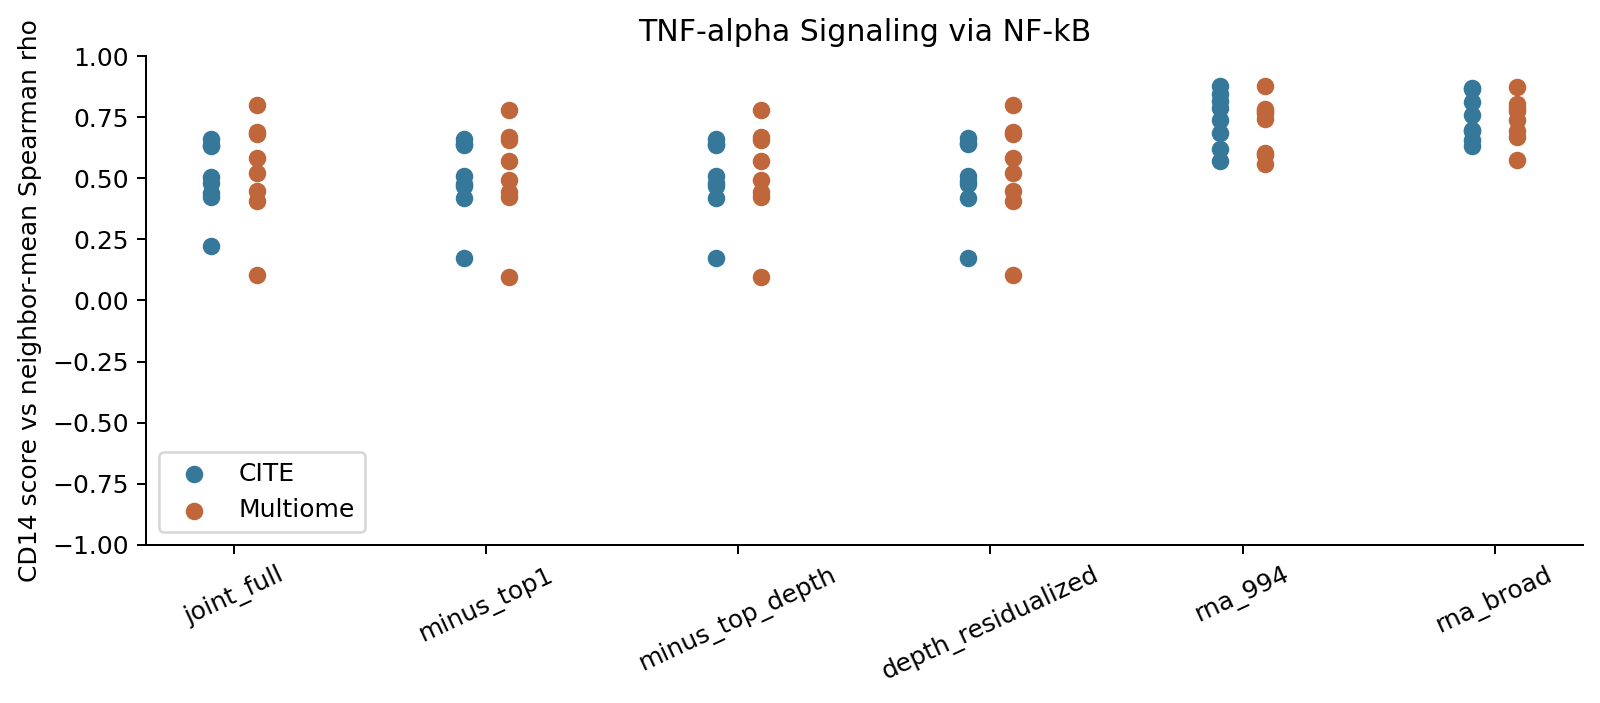

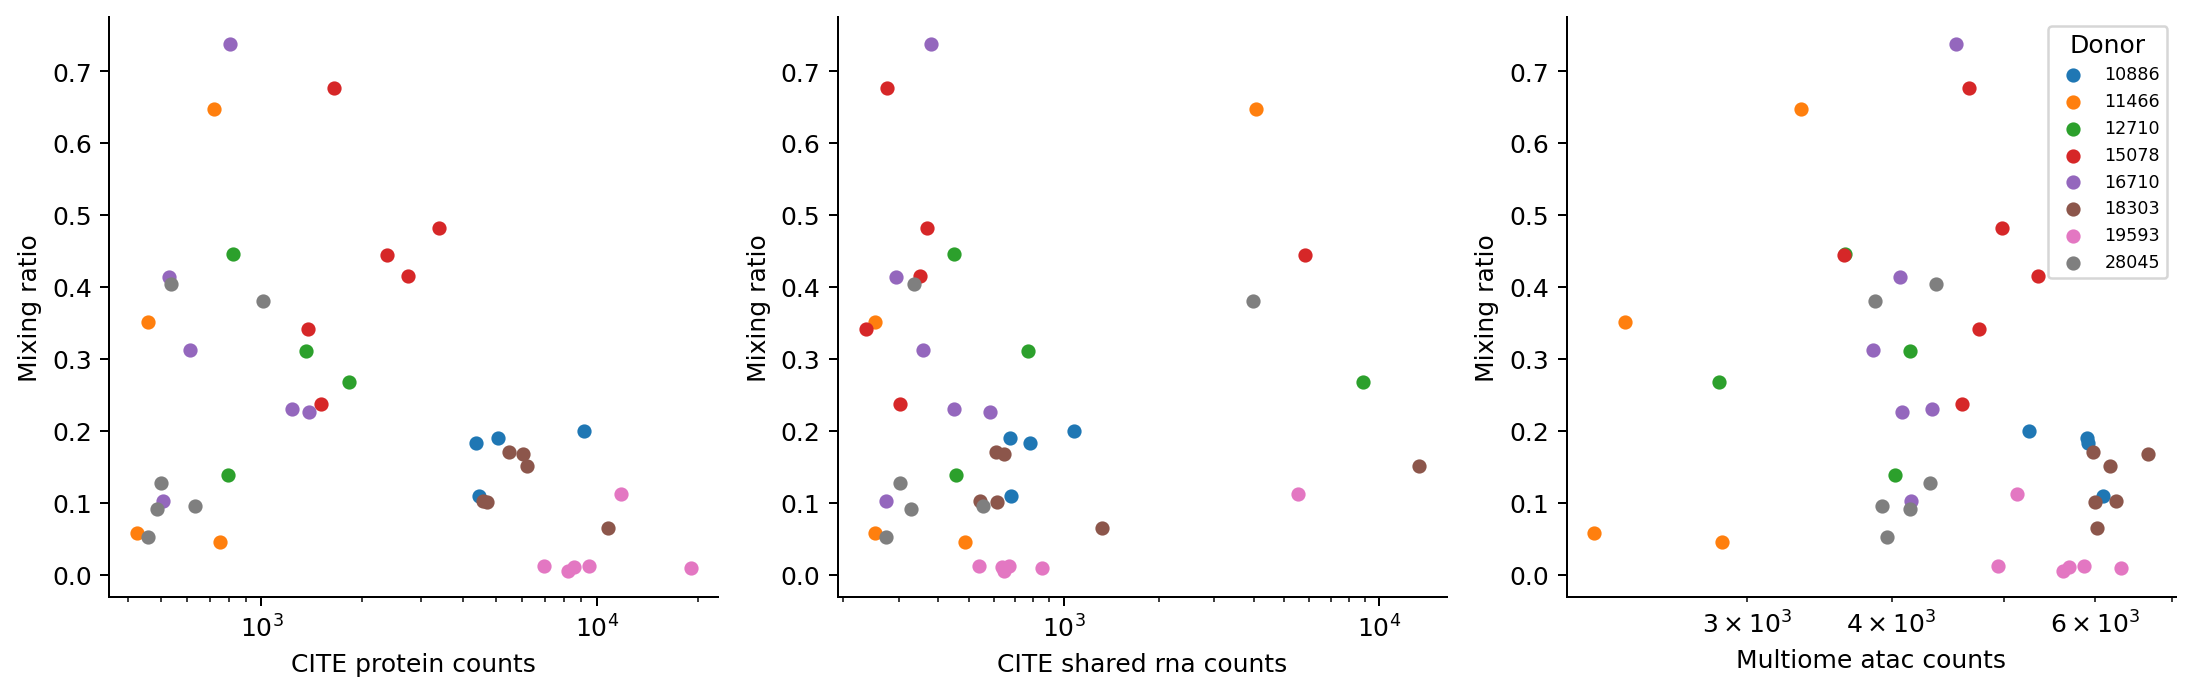

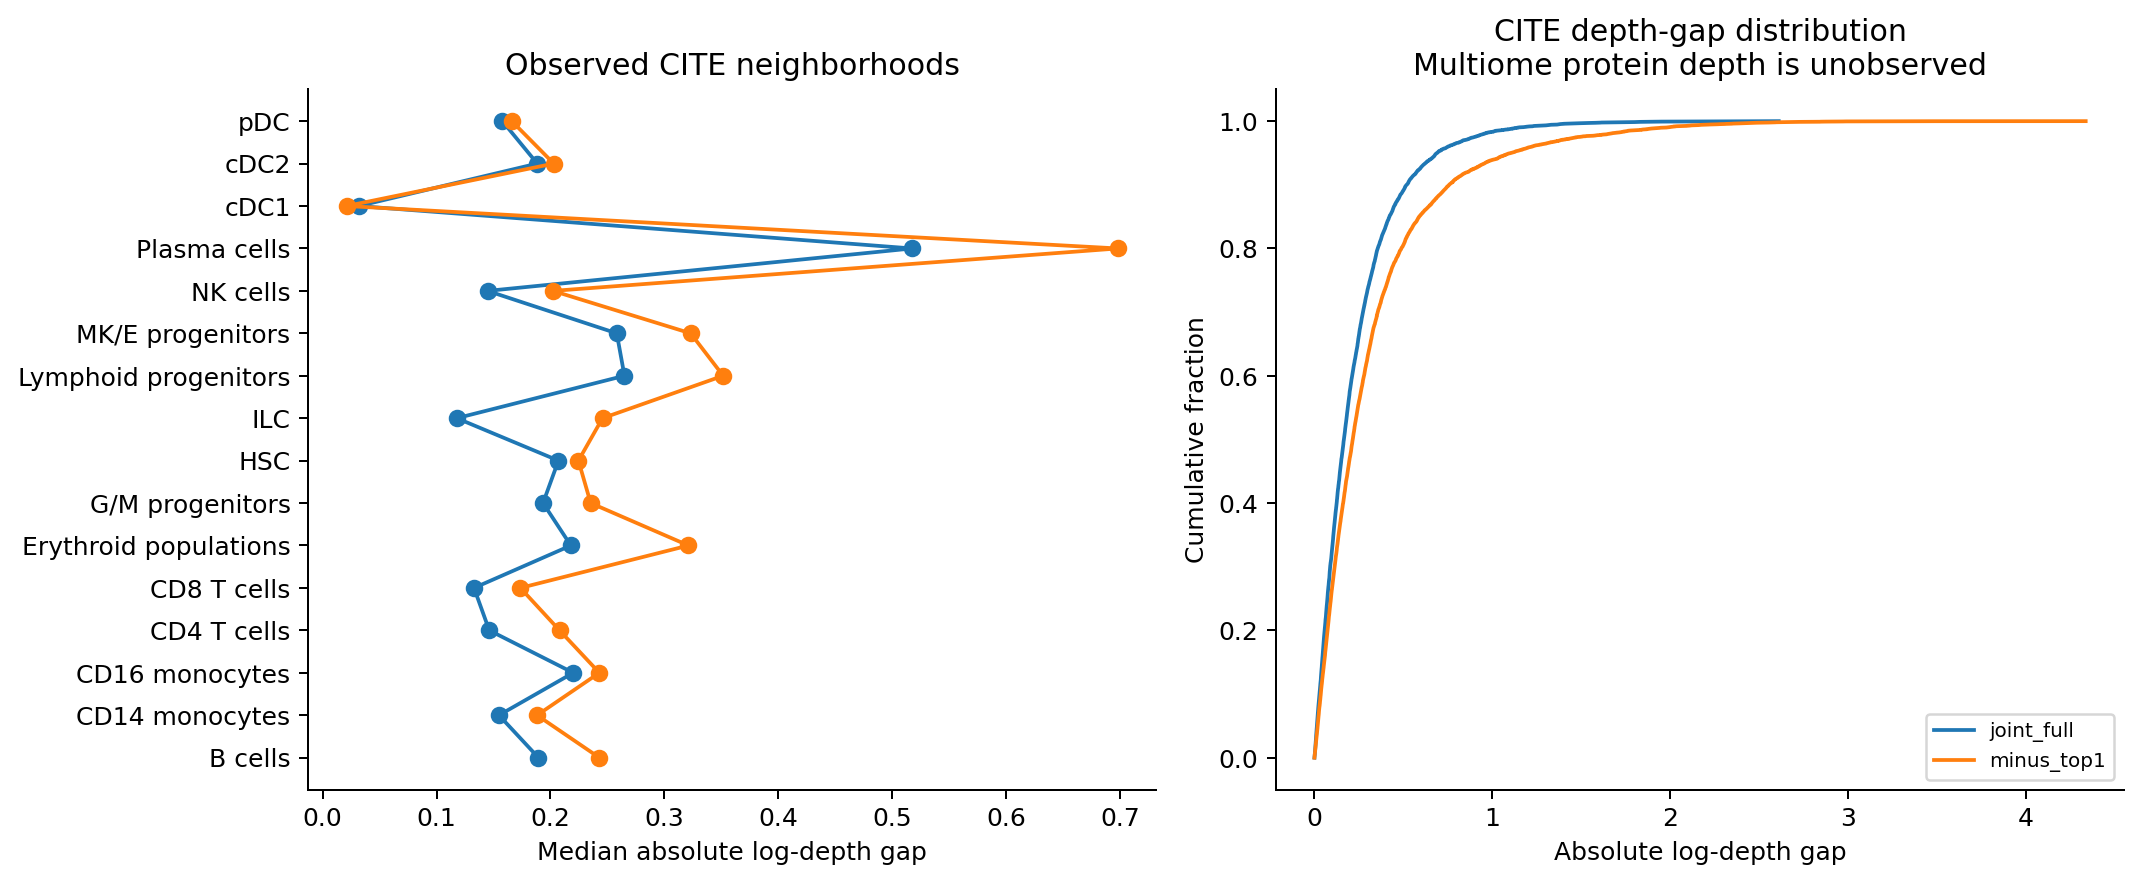

In [16]:
comparison, decisions, recommendation = run.finish()
display(comparison)
display(decisions)
for name in ['09_mixing_comparison','10_purity_comparison','11_celltype_alignment',
             '12_RNA_panel_comparison','13_module_retention','14_CD14_gradient',
             '15_CD14_gradient','16_alignment_vs_depth','17_neighbor_depth_dependence']:
    show_figure(name)

# 16. Decision before nb15

## Scientific question

What should change—or remain unchanged—before the next model?

## Why this diagnostic matters

The generated recommendation uses only executed diagnostics. No training-duration extension, coordinate deletion as a final correction, paired-cell interpretation, imputation validation, or ATAC→RNA→protein causality follows from these results.

In [17]:
display(Markdown(recommendation))
display(pd.read_json(run.output/'status.json', typ='series'))

# Main findings

Fixed nb13 evaluation: purity 90.6426%, cross-capture mixing 11.9727%; 11/13 cell types and 39/42 donor/type groups have concerns.

Coordinate 5 (zero-based) has median within-stratum |rho|=0.904 across 48 CITE donor/type strata; 7 coordinates have global CITE |rho|≥0.5.

Deleting the strongest coordinate changes mixing by +0.887 percentage points and purity by -0.227 points. Top-coordinate deletion changes mixing by +0.899 points; centered depth residualization by -0.115 points. Mean held-donor assay AUROC is 0.999999 in the full space and 0.999999 after single-coordinate deletion (decrease 9.1e-07).

Inflammatory Response: 34/200 original module genes retained (17.0%); TNF-alpha Signaling via NF-kB: 38/200 original module genes retained (19.0%). Gene coverage alone cannot establish loss of alignment information.

RNA-only PCA: 12,059 genes yield 86.91% purity and 0.26% mixing, versus 87.37% and 1.86% for 994 genes. The broader panel has 13/13 population concerns and 42/42 donor/type concerns.

# Diagnosis

H1 is unsupported; H2 is unresolved; H3 is unsupported. Identity purity and cross-capture alignment measure different properties: a representation can retain population boundaries while separating captures inside those populations. The supported diagnosis is persistent capture-specific structure in the remaining representation, with donor/site-associated and population-dependent patterns; a single protein-depth axis does not explain most of the failure. The perturbations test neighborhood sensitivity, not biological causality. Full-module assessment: full available RNA module scores; restricted vs full comparisons executed. These descriptive comparisons do not isolate a unique causal mechanism.

# Recommended next step

Option E, with a targeted diagnostic next step: retain the joint model only as a descriptive biological representation; do not rely on it for cross-capture alignment. Neither deleting depth-associated coordinates nor broadening the uncorrected RNA PCA panel demonstrates a sufficient alignment remedy. Before nb15, test capture effects within donor/site/population strata and assess population-aware integration against the saved full-module gradients. These findings do not establish that a broader panel would be ineffective in a retrained joint model. Require full-module gradient preservation before accepting any apparent mixing gain. Do not adopt coordinate deletion or label-informed residualization as the final correction. Longer training is not indicated by these diagnostics. Cells remain unpaired; missing-modality predictions and direct protein–ATAC relationships remain unvalidated.


state                                                    complete
completed       All locally available diagnostics executed; no...
unresolved                                                     []
needed_input                                                 None
dtype: object